In [2]:
# Importing necessary libraries
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import matplotlib.pyplot as plt

In [3]:
gdf = gpd.read_file('2010 Neighborhood Tabulation Areas (NTAs).geojson')

In [4]:
# Select a specific neighborhood in Manhattan
gdf_ngh = gdf[gdf.boro_name == 'Manhattan'].head(1)

In [5]:
# Load the tree census data and create a GeoDataFrame
tdf = pd.read_csv('2015_Street_Tree_Census_-_Tree_Data_20240618.csv', nrows=10000)
geometry = [Point(xy) for xy in zip(tdf['longitude'], tdf['latitude'])]
tdf = gpd.GeoDataFrame(tdf, geometry=geometry)[['tree_id', 'stump_diam', 'status', 'health', 'geometry']]
tdf.crs = 4326

In [6]:
# Transform the GeoDataFrames to the local CRS of New York City (EPSG:2263)
gdf_ngh_local = gdf_ngh.to_crs(2263)
tdf_local = tdf.to_crs(2263)

In [7]:
# Define a list of distance values for buffering
distances = [10, 1000, 10000, 25000, 50000, 75000]

Distance: 10 feet
Tree count: 30

Distance: 1000 feet
Tree count: 71

Distance: 10000 feet
Tree count: 1547

Distance: 25000 feet
Tree count: 4281

Distance: 50000 feet
Tree count: 7928

Distance: 75000 feet
Tree count: 9166



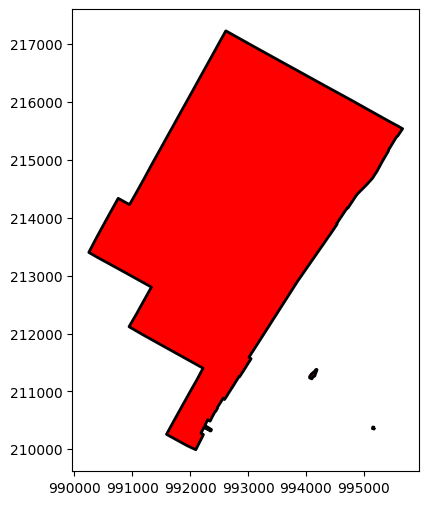

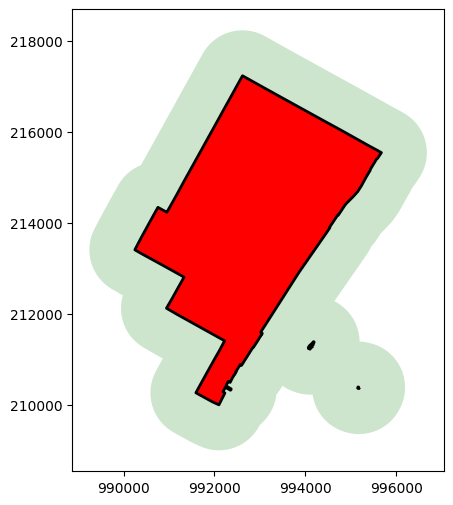

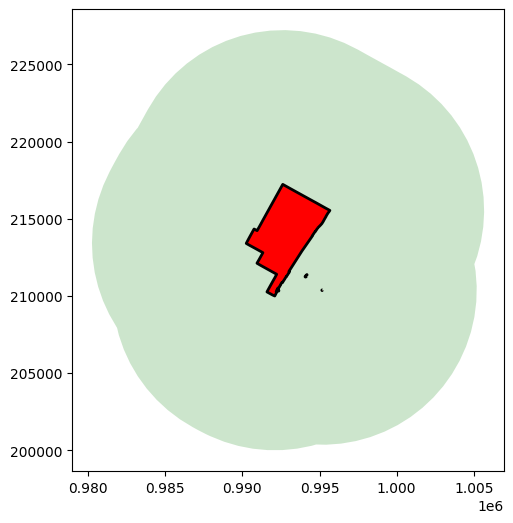

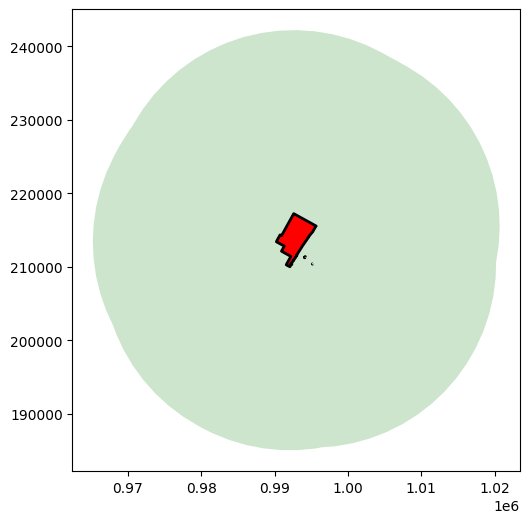

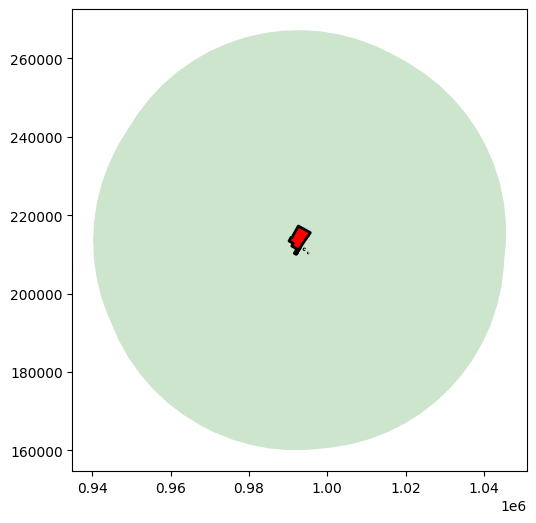

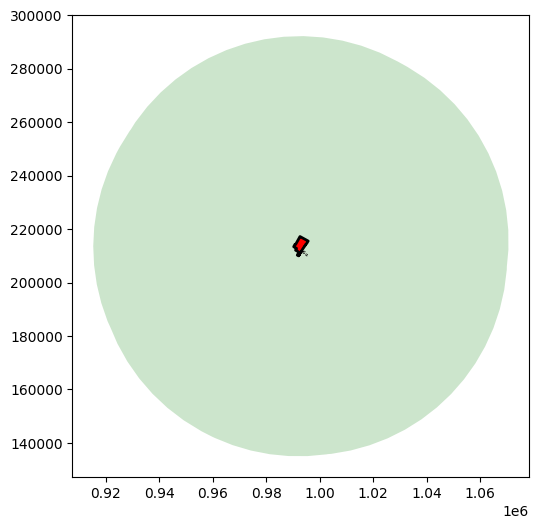

In [8]:
# Iterate over each distance, create buffers, and count trees within the buffer zone
for distance in distances:
    gdf_ngh_local_buffered = gdf_ngh_local.copy()
    gdf_ngh_local_buffered['geometry'] = gdf_ngh_local_buffered['geometry'].buffer(distance)
    gdf_joined = gpd.overlay(tdf_local, gdf_ngh_local_buffered, how='intersection')
    
    f, ax = plt.subplots(1, 1, figsize=(6, 6))
    gdf_ngh_local_buffered.plot(color='green', ax=ax, alpha=0.2)
    gdf_ngh_local.plot(color='red', ax=ax, edgecolor='k', linewidth=2)
    
    tree_count = len(gdf_joined['tree_id'].unique())
    print(f'Distance: {distance} feet')
    print(f'Tree count: {tree_count}')
    print()